# Visualizations

This notebook is for the Results-section figures. Each section writes reproducible tables and figures to `07_visualization/`.

## 0. Setup: paths, design system, and data loading

One shared setup cell for the whole notebook, consolidating the (near-duplicate) setup blocks from the three source notebooks.

In [6]:
from __future__ import annotations

import os
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from scipy.signal import periodogram
from scipy.stats import entropy
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
DATA_DIR = Path("C:/Python/CSUREMM/output")
OUTPUT_DIR = DATA_DIR / "07_visualizations"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "labels": DATA_DIR / "04_clustering" / "final_cluster_assignments.csv",
    "sax_vs_bert": DATA_DIR / "cluster_comparison" / "sax_vs_bert.csv",
    "panel_denoised": DATA_DIR / "01_preprocessing" / "panel_denoised.csv",
    "panel_normalized": DATA_DIR / "01_preprocessing" / "panel_normalized.csv",
    "mindist_tiebroken": DATA_DIR / "03_distance" / "sax_mindist_matrix_tiebroken.csv",
    #"quality": DATA_DIR / "04_clustering" / "all_cluster_quality_summary.csv",
}
for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required file [{name}]: {path}")

# ------------------------------------------------------------------
# Shared editorial design system (one palette used by every figure below)
# ------------------------------------------------------------------
INK = "#202124"
MUTED = "#6B7280"
GRID = "#D9DEE5"
PAPER = "#FFFFFF"
REFERENCE = "#8C929A"

CLUSTER_COLORS = {
    1: "#3B6FB6", 2: "#2A9D8F", 3: "#6C5CE7", 4: "#D97706", 5: "#C44569",
    6: "#7A9E3A", 7: "#0081A7", 8: "#8A5A44", 9: "#B23A48", 10: "#E76F51",
}

ARCHETYPE_COLORS = {
    "election_process": "#177E89",
    "candidate_breaking_news": "#D95D39",
}

STRATUM_COLORS = {
    "Celebrity/death or entertainment event": "#9C6ADE",
    "Banking/login or platform utility": "#2F80A3",
    "Singular news or shock event": "#D96C4A",
    "Lowest centroid correlation": "#7A6F64",
}

SEMANTIC_CMAP = LinearSegmentedColormap.from_list(
    "semantic_warm",
    ["#FFF8E8", "#F7D49A", "#E99A55", "#C95C3D", "#7F2D2D"],
)

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "text.color": INK, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.fontsize": 9, "pdf.fonttype": 42, "ps.fonttype": 42,
})

def editorial_axes(ax, *, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(length=0)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.7, alpha=0.65)
        ax.set_axisbelow(True)

def save_figure(fig, stem):
    fig.savefig(OUTPUT_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Figure output directory: {OUTPUT_DIR.resolve()}")


Data directory: C:\Python\CSUREMM\output
Figure output directory: C:\Python\CSUREMM\output\07_visualizations


### Load and validate the analysis universe

One aligned set of terms, panels, and distances feeds every figure below — no figure re-derives its own subset.

In [9]:
def load_panel(path: Path) -> pd.DataFrame:
    panel = pd.read_csv(path)
    date_col = panel.columns[0]
    panel[date_col] = pd.to_datetime(panel[date_col], errors="coerce")
    panel = panel.loc[panel[date_col].notna()].copy()
    panel = panel.set_index(date_col).sort_index()
    panel.index.name = "date"
    panel.columns = panel.columns.astype(str)
    return panel.apply(pd.to_numeric, errors="coerce")

labels = pd.read_csv(PATHS["labels"])
labels["term"] = labels["term"].astype("string")
labels = labels.loc[labels["term"].notna()].copy()
labels["term"] = labels["term"].str.strip()
labels["cluster"] = labels["cluster"].astype(int)

sax_vs_bert = pd.read_csv(PATHS["sax_vs_bert"])
sax_vs_bert["term"] = sax_vs_bert["term"].astype(str).str.strip()
sax_vs_bert["sax_cluster"] = sax_vs_bert["sax_cluster"].astype(int)
sax_vs_bert["bert_cluster"] = sax_vs_bert["bert_cluster"].astype(int)

panel_denoised = load_panel(PATHS["panel_denoised"])
panel_normalized = load_panel(PATHS["panel_normalized"])
#quality = pd.read_csv(PATHS["quality"])

mindist = pd.read_csv(PATHS["mindist_tiebroken"], index_col=0)
mindist.index = mindist.index.astype(str)
mindist.columns = mindist.columns.astype(str)
mindist = mindist.loc[mindist.index.intersection(mindist.columns)]
mindist = mindist.loc[:, mindist.index]
arr = mindist.to_numpy(dtype=float)
arr = (arr + arr.T) / 2.0
np.fill_diagonal(arr, 0.0)
mindist.iloc[:, :] = arr

common_terms = labels["term"].loc[labels["term"].isin(panel_normalized.columns) & labels["term"].isin(mindist.index)]
print(f"Final labeled terms: {len(labels):,}")
print(f"BERT-matched terms: {len(sax_vs_bert):,}")
print(f"Denoised panel: {panel_denoised.shape[0]:,} dates x {panel_denoised.shape[1]:,} columns")
print(f"Date range: {panel_denoised.index.min().date()} to {panel_denoised.index.max().date()}")
print(labels.groupby("cluster").size().rename("n_terms").to_string())


Final labeled terms: 846
BERT-matched terms: 846
Denoised panel: 1,612 dates x 847 columns
Date range: 2022-01-01 to 2026-05-31
cluster
1      42
2     115
3     226
4     116
5      28
6      37
7      73
8      74
9      26
10    109


## 1. Structural overview: what the clustering solution looks like

Before any interpretive claim, this figure orients the reader to the solution itself: five
representative terms per cluster (selected reproducibly as the lowest mean within-cluster MINDIST,
not hand-picked), their normalized trajectories over a shared recent window, and a matched
average-linkage dendrogram built from those same terms' precomputed MINDIST distances.

Note on scope: this is a dendrogram of the *50 selected representative terms*, not the full
847-term baseline dendrogram (`k=10`, Ward linkage) reported elsewhere in the Methodology section —
that full dendrogram is produced by the original pipeline notebook and isn't reproduced here to
avoid duplicating code paths across notebooks. This panel's job is orientation and readability, not
re-deriving the baseline clustering.


In [10]:
TOP_N_PER_CLUSTER = 5
SMOOTH_WINDOW = 7
DISPLAY_START = "2025-01-01"
DISPLAY_END = "2026-05-31"

# ---------------------------------------------------------------------
# Representative selection: lowest mean within-cluster MINDIST per cluster
# ---------------------------------------------------------------------
selected_records = []
for cluster_id in sorted(labels["cluster"].unique()):
    members = labels.loc[labels["cluster"].eq(cluster_id), "term"].tolist()
    members = [m for m in members if m in mindist.index]
    within = mindist.loc[members, members]
    mean_within_distance = within.mean(axis=1)
    representatives = mean_within_distance.sort_values(kind="stable").head(TOP_N_PER_CLUSTER)
    for rank, (term, value) in enumerate(representatives.items(), start=1):
        selected_records.append({
            "cluster": int(cluster_id), "rank_within_cluster": rank,
            "term": term, "mean_within_cluster_mindist": float(value),
        })

selected_term_table = pd.DataFrame(selected_records)
selected_terms = selected_term_table["term"].tolist()
assert selected_term_table.groupby("cluster").size().eq(TOP_N_PER_CLUSTER).all()
assert len(selected_terms) == 10 * TOP_N_PER_CLUSTER
selected_term_table.to_csv(OUTPUT_DIR / "structural_overview_selected_terms.csv", index=False)
display(selected_term_table)


,cluster,rank_within_cluster,term,mean_within_cluster_mindist
0,1,1,nba scores,24.439307
1,1,2,lightning game,24.907578
2,1,3,golden state warriors,25.277660
3,1,4,colorado avalanche,25.423339
4,1,5,boston celtics,25.471412
5,2,1,english to spanish,16.447284
6,2,2,spanish to english,16.447284
7,2,3,google,16.547201
8,2,4,translate,16.565221
9,2,5,timer,16.737076


In [11]:
# ---------------------------------------------------------------------
# Prepare trajectories and the matched (50-term) dendrogram
# ---------------------------------------------------------------------
panel_display = panel_normalized.loc[DISPLAY_START:DISPLAY_END, selected_terms].copy()
if panel_display.empty:
    raise ValueError("The requested display window contains no observations.")

# Re-standardize each displayed series within the shown window, for shape comparison only.
plot_matrix = panel_display.T
plot_matrix = plot_matrix.sub(plot_matrix.mean(axis=1), axis=0)
row_sd = plot_matrix.std(axis=1).replace(0, np.nan)
plot_matrix = plot_matrix.div(row_sd, axis=0).fillna(0.0)

# Visual smoothing only (does not feed back into any clustering or statistic).
plot_matrix_smooth = plot_matrix.T.rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().T

selected_dist = mindist.loc[selected_terms, selected_terms]
condensed = squareform(selected_dist.to_numpy(dtype=float), checks=False)
Z_selected = linkage(condensed, method="average")

dendro_info = dendrogram(Z_selected, orientation="right", no_plot=True, labels=selected_terms)
ordered_terms = dendro_info["ivl"]
plot_matrix_smooth = plot_matrix_smooth.loc[ordered_terms]
term_to_cluster = labels.set_index("term")["cluster"].astype(int).to_dict()

print(f"Display window: {panel_display.index.min().date()} to {panel_display.index.max().date()}")
print(f"Rows plotted: {len(ordered_terms)}")


Display window: 2025-01-01 to 2026-05-31
Rows plotted: 50


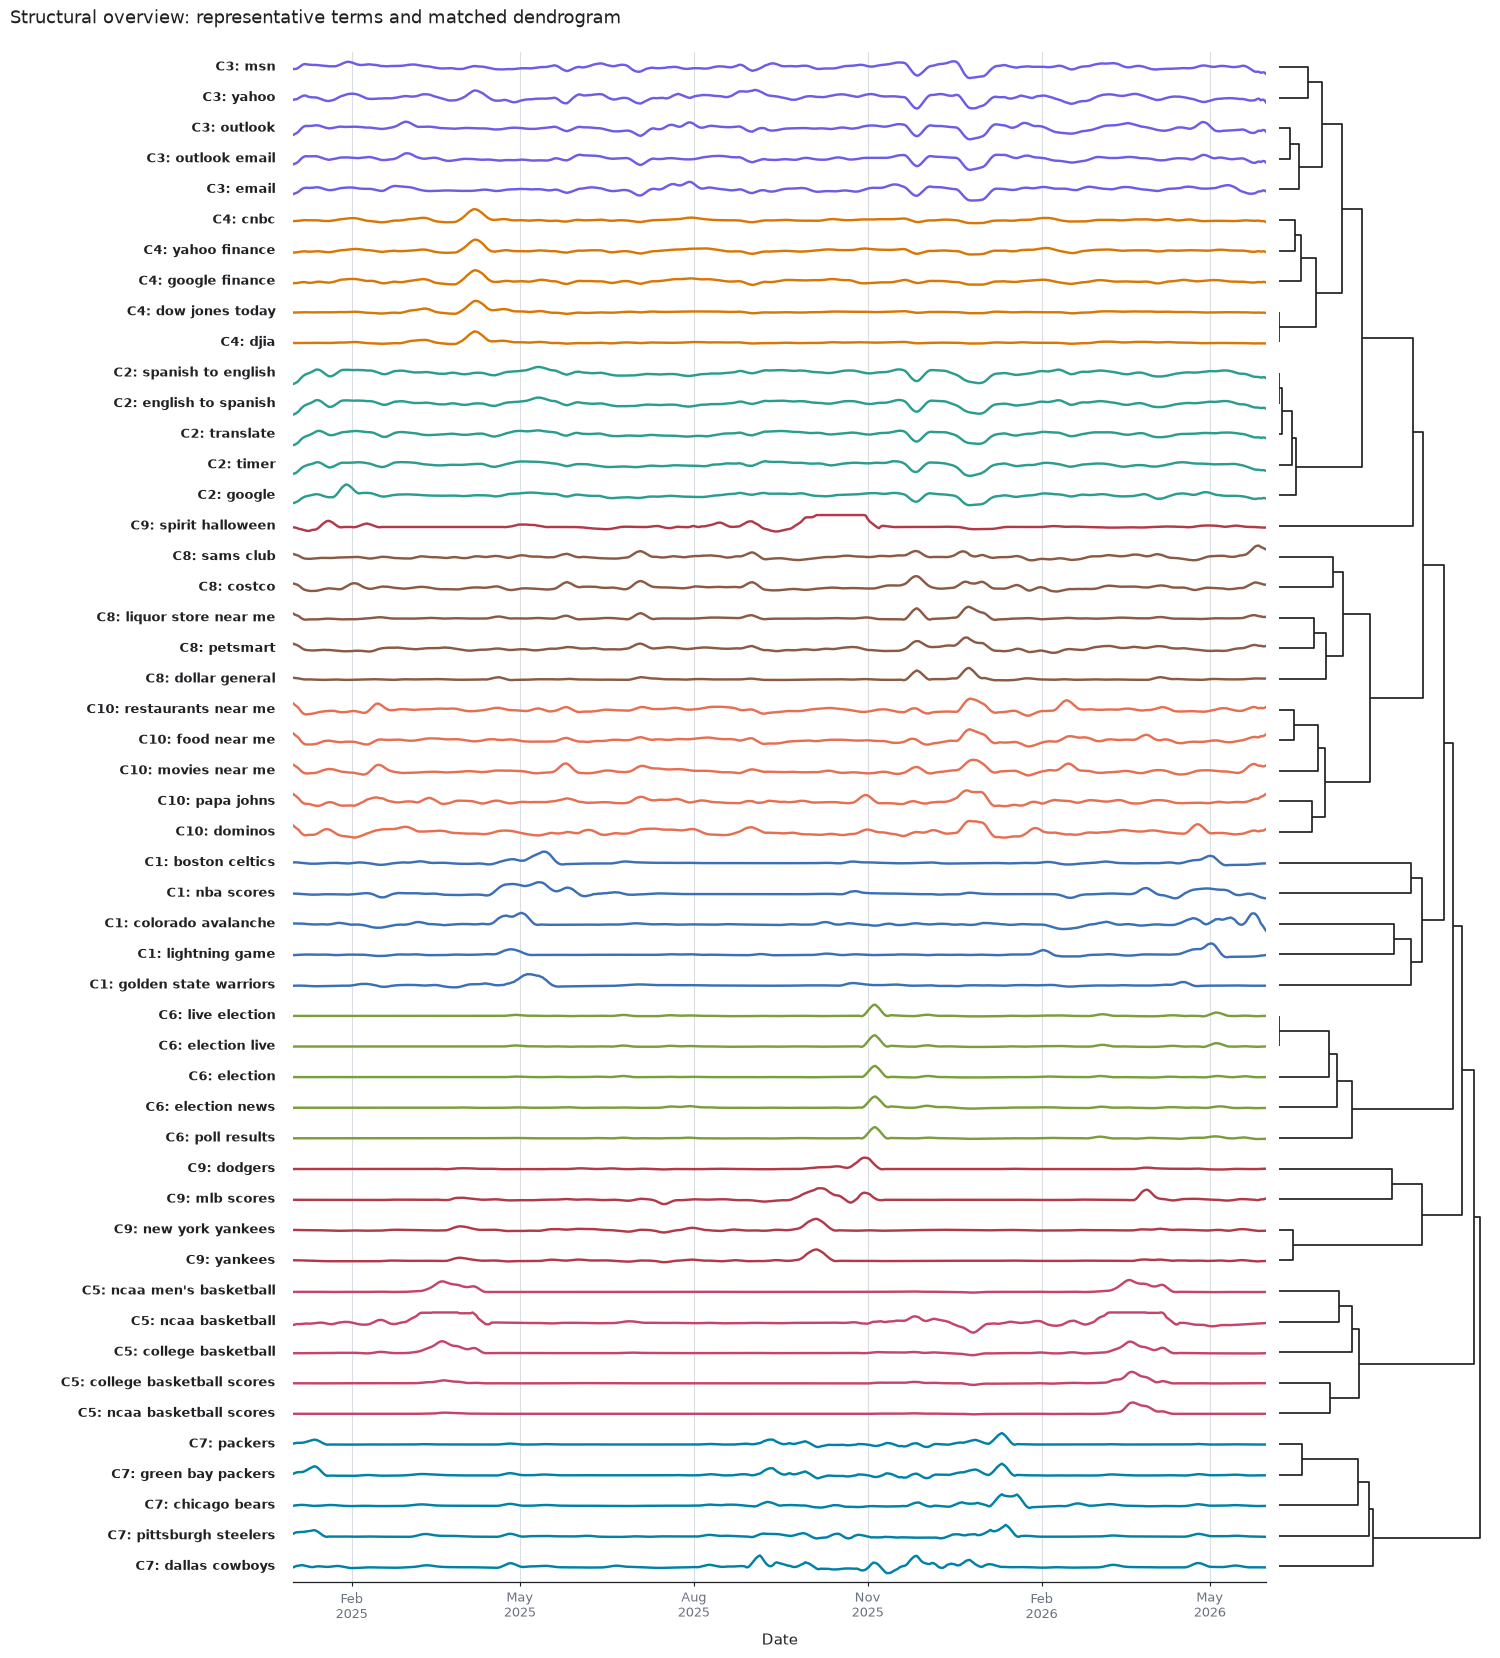

In [ ]:
# ---------------------------------------------------------------------
# Classic three-part panel: labels | trajectories | dendrogram
# ---------------------------------------------------------------------
n_rows = len(ordered_terms)
FIG_HEIGHT_PER_ROW = 0.34
LANE_HEIGHT = 3.6
LINEWIDTH = 1.75

y_positions = np.arange(n_rows) * 10 + 5   # matches scipy dendrogram leaf coordinates
ylim = (0, n_rows * 10)
fig_height = max(13, FIG_HEIGHT_PER_ROW * n_rows)

fig = plt.figure(figsize=(15.5, fig_height))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[3.2, 11.5, 2.5], wspace=0.025)
ax_labels = fig.add_subplot(gs[0, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_den = fig.add_subplot(gs[0, 2])

# Left labels
ax_labels.set_xlim(0, 1); ax_labels.set_ylim(*ylim); ax_labels.axis("off")
for i, term in enumerate(ordered_terms):
    cluster_id = term_to_cluster[term]
    ax_labels.text(0.98, y_positions[i], f"C{cluster_id}: {term}", ha="right", va="center",
                   fontsize=9.5, fontweight="bold", color=INK)

# Middle trajectories
dates = pd.to_datetime(plot_matrix_smooth.columns)
for i, term in enumerate(ordered_terms):
    cluster_id = term_to_cluster[term]
    y = plot_matrix_smooth.loc[term].to_numpy(dtype=float)
    max_abs = np.nanmax(np.abs(y))
    y_scaled = np.zeros_like(y) if not np.isfinite(max_abs) or max_abs == 0 else y / max_abs * LANE_HEIGHT
    ax_ts.plot(dates, y_positions[i] + y_scaled, color=CLUSTER_COLORS[cluster_id],
               linewidth=LINEWIDTH, solid_capstyle="round")

ax_ts.set_ylim(*ylim); ax_ts.set_yticks([])
ax_ts.set_xlim(dates.min(), dates.max())
ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax_ts.set_xlabel("Date", labelpad=8)
ax_ts.grid(axis="x", color=GRID, linewidth=0.8)
ax_ts.grid(axis="y", visible=False)
ax_ts.tick_params(axis="x", length=3, color=INK)
for spine in ["left", "right", "top"]:
    ax_ts.spines[spine].set_visible(False)
ax_ts.spines["bottom"].set_color(INK)
ax_ts.spines["bottom"].set_linewidth(0.9)

# Right dendrogram
dendrogram(Z_selected, orientation="right", labels=selected_terms, ax=ax_den,
           color_threshold=None, above_threshold_color=INK, link_color_func=lambda _: INK)
ax_den.set_ylim(*ylim); ax_den.set_yticklabels([]); ax_den.set_xticks([])
ax_den.tick_params(left=False, bottom=False)
for collection in ax_den.collections:
    collection.set_linewidth(1.25)
for spine in ["left", "right", "top", "bottom"]:
    ax_den.spines[spine].set_visible(False)

#fig.suptitle("Structural overview: representative terms and matched dendrogram", x=0.03, y=0.995,
#             ha="left", fontsize=13)
fig.subplots_adjust(left=0.03, right=0.985, top=0.97, bottom=0.07)

save_figure(fig, "structural_overview_panel")
plt.show()


**Figure construction notes.** Five terms are shown per final cluster, selected by minimum average
within-cluster MINDIST (reproducible, not hand-picked). Displayed trajectories are re-standardized
within the shown window and rescaled per row for shape comparison, so vertical amplitude is *not*
comparable across rows — only timing and shape are. The 7-day rolling mean is for visual smoothing
only. The dendrogram reflects the relationships among these 50 selected terms specifically, not a
re-fit of the full 847-term baseline solution.


## 2. Centerpiece: the election split — one semantic category, two temporal behaviors

A predefined financial-sentiment dictionary would place `election results`, `electoral college`,
`trump`, and `kamala harris` in a single bucket: they are all, lexically, election terms. Our
clustering places them in two — Cluster 2 (civic-ritual/process terms) and Cluster 10
(candidate-name terms, which behave like breaking news). This is the single figure that proves the
paper's central claim rather than merely illustrating it.


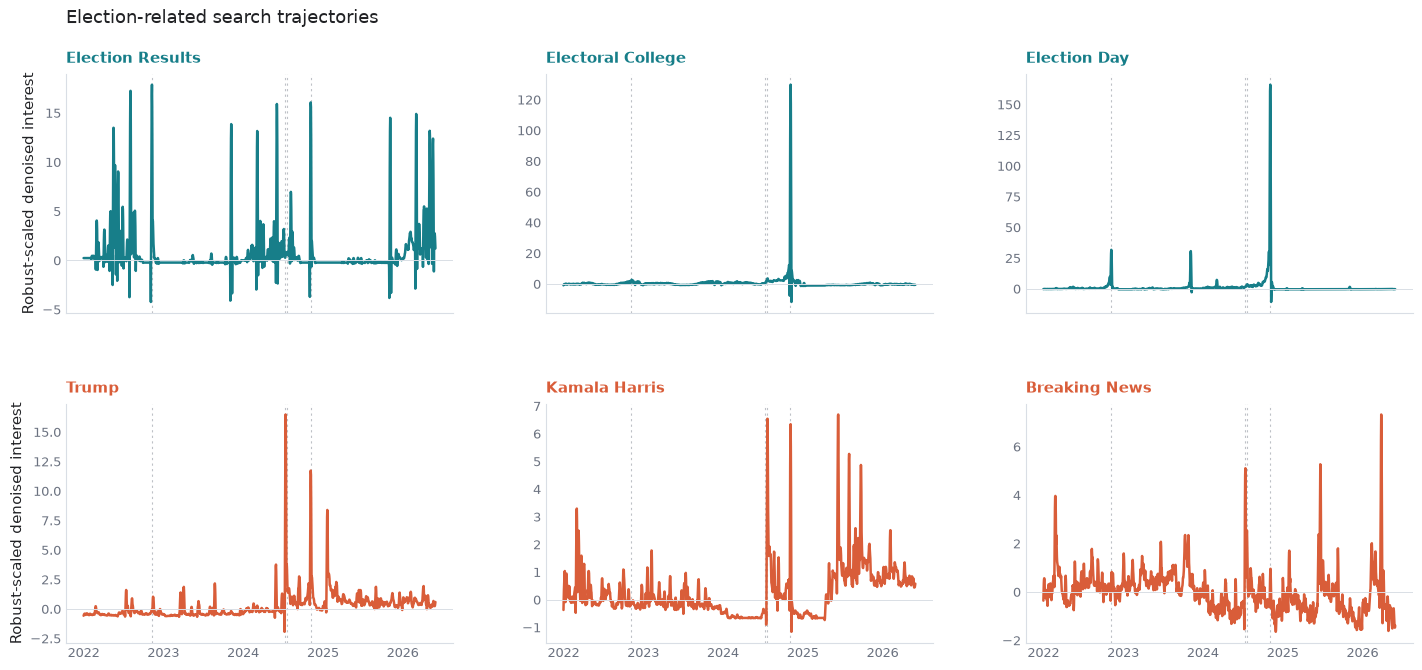

Election-split caption facts:


,date,event
0,2022-11-08,2022 U.S. Election Day
1,2024-07-13,Trump rally assassination attempt
2,2024-07-21,Biden withdrew and endorsed Harris
3,2024-11-05,2024 U.S. Election Day


In [13]:
# Major-date sources used only to document the caption facts:
# 2022 U.S. general election, 2022-11-08: https://www.congress.gov/117/crec/2022/11/14/168/174/CREC-2022-11-14.pdf
# Trump rally assassination attempt, 2024-07-13: https://www.secretservice.gov/newsroom/releases/2025/07/us-secret-service-one-year-update-following-july-13-2024-attempted
# Biden withdrew and endorsed Harris, 2024-07-21: https://www.ap.org/news-highlights/elections/2024/biden-drops-out-of-2024-race-after-disastrous-debate-inflamed-age-concerns-vp-harris-gets-his-nod/
# 2024 U.S. presidential general election, 2024-11-05: https://www.archives.gov/electoral-college/2024

ELECTION_TERMS = ["election results", "electoral college", "election day"]
NEWS_TERMS = ["trump", "kamala harris", "breaking news"]
EVENTS = [
    (pd.Timestamp("2022-11-08"), "2022 U.S. Election Day"),
    (pd.Timestamp("2024-07-13"), "Trump rally assassination attempt"),
    (pd.Timestamp("2024-07-21"), "Biden withdrew and endorsed Harris"),
    (pd.Timestamp("2024-11-05"), "2024 U.S. Election Day"),
]

def robust_rescale(series: pd.Series) -> pd.Series:
    s = series.astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    scale = q3 - q1
    if not np.isfinite(scale) or scale == 0:
        scale = s.std(ddof=0)
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0
    return (s - s.median()) / scale

plot_terms = ELECTION_TERMS + NEWS_TERMS
scaled = panel_denoised[plot_terms].apply(robust_rescale)

fig, axes = plt.subplots(2, 3, figsize=(14.8, 7.2), sharex=True, sharey=False)
row_specs = [
    (ELECTION_TERMS, ARCHETYPE_COLORS["election_process"]),
    (NEWS_TERMS, ARCHETYPE_COLORS["candidate_breaking_news"]),
]
for row, (terms, line_color) in enumerate(row_specs):
    for col, term in enumerate(terms):
        ax = axes[row, col]
        ax.plot(scaled.index, scaled[term], color=line_color, linewidth=1.8, solid_capstyle="round")
        ax.axhline(0, color=GRID, linewidth=0.7)
        for event_date, _ in EVENTS:
            if scaled.index.min() <= event_date <= scaled.index.max():
                ax.axvline(event_date, color="#A8ADB4", linestyle=(0, (2, 3)), linewidth=0.8, alpha=0.75, zorder=0)
        ax.set_title(term.title(), loc="left", fontsize=11, pad=8, color=line_color)
        editorial_axes(ax, grid_axis=None)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[0, 0].set_ylabel("Robust-scaled denoised interest")
axes[1, 0].set_ylabel("Robust-scaled denoised interest")
fig.suptitle("Election-related search trajectories", x=0.075, y=0.98, ha="left", fontsize=13)
fig.subplots_adjust(top=0.89, left=0.075, right=0.985, bottom=0.10, hspace=0.38, wspace=0.24)

save_figure(fig, "election_split")
plt.show()

election_caption_facts = pd.DataFrame([{"date": d.date().isoformat(), "event": e} for d, e in EVENTS])
print("Election-split caption facts:")
display(election_caption_facts)


The common robust scale is used only for visual comparability; it preserves timing and relative within-series shape, not absolute magnitude across panels.

## 3. Validity check 1: semantic composition and entropy

Semantic categories come from an independent BERT/MPNet clustering of the same terms — no hand-built topic dictionary is introduced. If SAX clusters were arbitrary, their semantic composition should look uniform; instead, several are recovered as nearly pure without ever being given a topic label.

In [ ]:
BERT_LABELS = {
    1: "Tournaments", 2: "Teams", 3: "Women", 4: "Celebrities", 5: "Elections",
    6: "Retail", 7: "Weather", 8: "News", 9: "Finance", 10: "Services",
}
missing_bert_ids = set(sax_vs_bert["bert_cluster"]) - set(BERT_LABELS)
if missing_bert_ids:
    raise ValueError(f"Missing readable labels for BERT clusters: {missing_bert_ids}")

composition_counts = pd.crosstab(sax_vs_bert["sax_cluster"], sax_vs_bert["bert_cluster"]).reindex(
    index=range(1, 11), columns=sorted(BERT_LABELS), fill_value=0
)
composition_share = composition_counts.div(composition_counts.sum(axis=1), axis=0)

def shannon_bits(row: pd.Series) -> float:
    p = row.to_numpy(dtype=float)
    p = p[p > 0]
    return float(entropy(p, base=2)) if len(p) else np.nan

entropy_table = pd.DataFrame({
    "cluster": composition_share.index,
    "topic_entropy_bits": composition_share.apply(shannon_bits, axis=1).to_numpy(),
    "dominant_bert_cluster": composition_share.idxmax(axis=1).to_numpy(),
    "dominant_share": composition_share.max(axis=1).to_numpy(),
})
entropy_table["dominant_semantic_category"] = entropy_table["dominant_bert_cluster"].map(BERT_LABELS)
entropy_table = entropy_table.sort_values("topic_entropy_bits").reset_index(drop=True)
display(entropy_table)
entropy_table.to_csv(OUTPUT_DIR / "cluster_bert_entropy.csv", index=False)
composition_share.to_csv(OUTPUT_DIR / "cluster_bert_composition_share.csv")


,cluster,topic_entropy_bits,dominant_bert_cluster,dominant_share,dominant_semantic_category
0,7,0.242292,1,0.960000,Tournaments
1,2,0.643415,5,0.869565,Elections
2,9,1.422115,9,0.638298,Finance
3,3,1.428898,2,0.650000,Teams
4,1,1.492055,8,0.752809,News
5,4,1.704573,2,0.500000,Teams
6,6,1.725709,8,0.412500,News
7,5,1.880191,6,0.388889,Retail
8,10,2.229765,8,0.488636,News
9,8,2.409001,8,0.431894,News


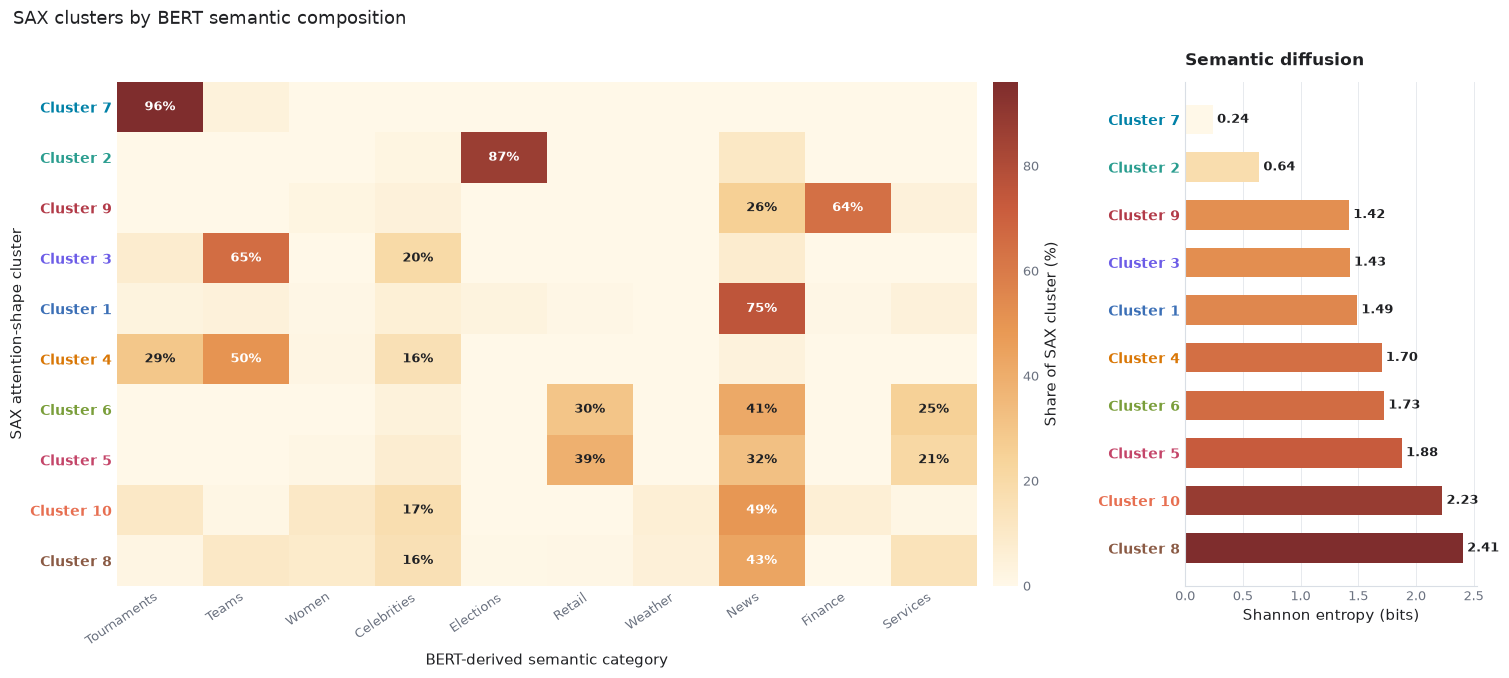

Heatmap and entropy caption facts:


,cluster,topic_entropy_bits,dominant_bert_cluster,dominant_semantic_category,dominant_share
0,7,0.242292,1,Tournaments,0.9600
1,2,0.643415,5,Elections,0.8696
2,9,1.422115,9,Finance,0.6383
3,3,1.428898,2,Teams,0.6500
4,1,1.492055,8,News,0.7528
5,4,1.704573,2,Teams,0.5000
6,6,1.725709,8,News,0.4125
7,5,1.880191,6,Retail,0.3889
8,10,2.229765,8,News,0.4886
9,8,2.409001,8,News,0.4319


In [15]:
row_order = entropy_table.sort_values(["topic_entropy_bits", "cluster"])["cluster"].astype(int).tolist()
heat_ordered = composition_share.loc[row_order] * 100
entropy_ordered = entropy_table.set_index("cluster").loc[row_order].reset_index()

fig = plt.figure(figsize=(16.0, 8.0))
gs = fig.add_gridspec(1, 2, width_ratios=[3.55, 1.15], wspace=0.28)
ax_hm = fig.add_subplot(gs[0, 0])
ax_ent = fig.add_subplot(gs[0, 1])

im = ax_hm.imshow(heat_ordered.to_numpy(), aspect="auto", interpolation="nearest", cmap=SEMANTIC_CMAP,
                   vmin=0, vmax=max(60, float(np.nanmax(heat_ordered.to_numpy()))))
ax_hm.set_xticks(np.arange(len(BERT_LABELS)))
ax_hm.set_xticklabels([BERT_LABELS[i] for i in sorted(BERT_LABELS)], rotation=34, ha="right", fontsize=9)
ax_hm.set_yticks(np.arange(len(row_order)))
ax_hm.set_yticklabels([f"Cluster {c}" for c in row_order], fontsize=10)
ax_hm.set_xlabel("BERT-derived semantic category")
ax_hm.set_ylabel("SAX attention-shape cluster")

for r, cluster in enumerate(row_order):
    for c, value in enumerate(heat_ordered.loc[cluster].to_numpy()):
        if value >= 15:
            text_color = "white" if value >= 42 else INK
            ax_hm.text(c, r, f"{value:.0f}%", ha="center", va="center", fontsize=9, fontweight="bold", color=text_color)

ax_hm.tick_params(length=0)
for spine in ax_hm.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax_hm, fraction=0.028, pad=0.018)
cbar.set_label("Share of SAX cluster (%)")
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

entropy_values = entropy_ordered["topic_entropy_bits"].to_numpy()
entropy_norm = Normalize(vmin=float(np.nanmin(entropy_values)), vmax=float(np.nanmax(entropy_values)))
bar_colors = [SEMANTIC_CMAP(entropy_norm(v)) for v in entropy_values]
y = np.arange(len(entropy_ordered))

ax_ent.barh(y, entropy_values, color=bar_colors, height=0.62, edgecolor="none")
ax_ent.set_yticks(y)
ax_ent.set_yticklabels([f"Cluster {c}" for c in entropy_ordered["cluster"]], fontsize=10)
ax_ent.invert_yaxis()
ax_ent.set_xlabel("Shannon entropy (bits)")
ax_ent.set_title("Semantic diffusion", loc="left", fontsize=12, pad=12)
editorial_axes(ax_ent, grid_axis="x")
ax_ent.grid(axis="y", visible=False)
for yi, value in zip(y, entropy_values):
    ax_ent.text(value + 0.035, yi, f"{value:.2f}", va="center", fontsize=9, fontweight="bold", color=INK)

for tick, cluster in zip(ax_hm.get_yticklabels(), row_order):
    tick.set_color(CLUSTER_COLORS[int(cluster)]); tick.set_fontweight("bold")
for tick, cluster in zip(ax_ent.get_yticklabels(), entropy_ordered["cluster"]):
    tick.set_color(CLUSTER_COLORS[int(cluster)]); tick.set_fontweight("bold")

fig.suptitle("SAX clusters by BERT semantic composition", x=0.055, y=0.98, ha="left", fontsize=13)
fig.subplots_adjust(top=0.89, left=0.12, right=0.97, bottom=0.26)

save_figure(fig, "topic_heatmap_entropy")
plt.show()

heatmap_caption_facts = entropy_ordered[["cluster", "topic_entropy_bits", "dominant_bert_cluster", "dominant_semantic_category", "dominant_share"]].copy()
heatmap_caption_facts["dominant_share"] = heatmap_caption_facts["dominant_share"].round(4)
print("Heatmap and entropy caption facts:")
display(heatmap_caption_facts)


Entropy is computed directly from the independent `bert_cluster` assignments; this supersedes any earlier heuristic-keyword-tagger entropy values, which should not be reported alongside this figure to avoid duplicating the same claim with a weaker method.

## 4. Validity check 2: periodicity collision (Clusters 4 and 9)

Clusters 4 (74% sports, largely NFL) and 9 (70% finance/markets) share a dominant period of
exactly 7 days despite almost no topical overlap. We show this explicitly and flag it honestly:
shared periodicity here reflects two unrelated institutional calendars (a weekend game schedule; a
Monday-Friday trading week) independently stamping the same period onto unrelated search behavior —
not a substantive link between sports and markets. Presenting this as a *discovered connection*
would be exactly the kind of overreading the Google Flu Trends cautionary tale warns against.


In [ ]:
def robust_centroid(panel: pd.DataFrame, terms: list[str]) -> pd.Series:
    available = [t for t in terms if t in panel.columns]
    if not available:
        raise ValueError("No requested terms are present in the panel.")
    return panel[available].median(axis=1, skipna=True)

def periodicity_diagnostics(series: pd.Series, min_period_days: int = 2, max_period_days: int = 60) -> pd.DataFrame:
    s = series.replace([np.inf, -np.inf], np.nan).interpolate().dropna()
    frequencies, power = periodogram(s.to_numpy(dtype=float), fs=1.0, detrend="linear", scaling="spectrum")
    valid = frequencies > 0
    frequencies, power = frequencies[valid], power[valid]
    periods = 1.0 / frequencies
    keep = (periods >= min_period_days) & (periods <= max_period_days)
    return pd.DataFrame({"period_days": periods[keep], "power": power[keep]}).sort_values("period_days")

cluster_terms = labels.groupby("cluster")["term"].apply(list).to_dict()
centroid_4 = robust_centroid(panel_normalized, cluster_terms[4])
centroid_9 = robust_centroid(panel_normalized, cluster_terms[9])
p4 = periodicity_diagnostics(centroid_4)
p9 = periodicity_diagnostics(centroid_9)
peak4 = p4.loc[p4["power"].idxmax()]
peak9 = p9.loc[p9["power"].idxmax()]
print(f"Cluster 4 dominant period: {peak4['period_days']:.2f} days")
print(f"Cluster 9 dominant period: {peak9['period_days']:.2f} days")


In [ ]:
fig, ax = plt.subplots(figsize=(10.6, 5.7))
ax.axvspan(6.5, 7.5, color="#F4D7A1", alpha=0.45, zorder=0)
ax.plot(p4["period_days"], p4["power"], color=CLUSTER_COLORS[4], linewidth=2.6, solid_capstyle="round", label="Cluster 4")
ax.plot(p9["period_days"], p9["power"], color=CLUSTER_COLORS[9], linewidth=2.6, solid_capstyle="round", label="Cluster 9")
ax.set_xlim(2, 30)
ax.set_xlabel("Period (days)")
ax.set_ylabel("Spectral power")
ax.set_title("Cluster centroid periodograms", loc="left", fontsize=13, pad=12)
editorial_axes(ax, grid_axis=None)
ax.legend(loc="upper right", frameon=False, ncol=2)
fig.subplots_adjust(top=0.90, left=0.10, right=0.97, bottom=0.14)

save_figure(fig, "periodicity_collision")
plt.show()

periodicity_caption_facts = pd.DataFrame([
    {"cluster": 4, "dominant_period_days": float(peak4["period_days"]), "peak_power": float(peak4["power"]), "line_color": CLUSTER_COLORS[4]},
    {"cluster": 9, "dominant_period_days": float(peak9["period_days"]), "peak_power": float(peak9["power"]), "line_color": CLUSTER_COLORS[9]},
])
print("Periodicity caption facts:")
display(periodicity_caption_facts)


## 5. Honest limits: Cluster 8 heterogeneity

Cluster 8 holds 301 of 847 terms (35.5%), has the only negative silhouette in the solution, and
the lowest consensus. Plotting several member trajectories directly — rather than the reported
centroid alone — shows why: one-off celebrity deaths, financial-institution logins, and singular
news events sit side by side with no shared rise-and-fall pattern. This is a substantive finding
about the limits of the pipeline's monitoring value, not a tuning artifact.


In [ ]:
def correlation_to_centroid(panel: pd.DataFrame, terms: list[str], centroid: pd.Series) -> pd.Series:
    available = [t for t in terms if t in panel.columns]
    return panel[available].corrwith(centroid).sort_values()

cluster8_terms = cluster_terms[8]
cluster8_centroid = robust_centroid(panel_normalized, cluster8_terms)
cluster8_corr = correlation_to_centroid(panel_normalized, cluster8_terms, cluster8_centroid)

STRATA_KEYWORDS = {
    "Celebrity/death or entertainment event": ["gene hackman", "bob newhart", "betty white", "meat loaf", "johnny depp", "amber heard", "shannen doherty", "coolio"],
    "Banking/login or platform utility": ["us bank", "bank of america", "capital one login", "chase login", "fidelity login", "gmail login", "facebook login", "huntington bank"],
    "Singular news or shock event": ["mh370", "crowdstrike", "ftx", "hurricane ian", "breaking news", "flash flood warning", "dahmer", "ukraine"],
}
selected_rows = []
for stratum, candidates in STRATA_KEYWORDS.items():
    valid = [t for t in candidates if t in cluster8_corr.index]
    chosen = cluster8_corr.loc[valid].sort_values().head(3).index.tolist()
    for term in chosen:
        selected_rows.append({"stratum": stratum, "term": term, "centroid_correlation": float(cluster8_corr.loc[term])})
selected_cluster8 = pd.DataFrame(selected_rows)
if selected_cluster8["term"].nunique() < 6:
    fallback = cluster8_corr.head(9).index.tolist()
    selected_cluster8 = pd.DataFrame({"stratum": "Lowest centroid correlation", "term": fallback, "centroid_correlation": cluster8_corr.loc[fallback].to_numpy()})
display(selected_cluster8)
selected_cluster8.to_csv(OUTPUT_DIR / "cluster8_selected_members.csv", index=False)


In [ ]:
stratum_order = ["Celebrity/death or entertainment event", "Banking/login or platform utility", "Singular news or shock event", "Lowest centroid correlation"]
selected_plot = selected_cluster8.copy()
selected_plot["stratum"] = pd.Categorical(selected_plot["stratum"], categories=stratum_order, ordered=True)
selected_plot = selected_plot.sort_values(["stratum", "centroid_correlation"]).reset_index(drop=True)

terms8 = selected_plot["term"].drop_duplicates().tolist()
ncols = 3
nrows = math.ceil(len(terms8) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14.8, 3.05 * nrows), sharex=True, sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, row in zip(axes, selected_plot.itertuples(index=False)):
    term = row.term
    stratum = str(row.stratum)
    accent = STRATUM_COLORS.get(stratum, STRATUM_COLORS["Lowest centroid correlation"])
    ax.plot(panel_normalized.index, panel_normalized[term], color=accent, linewidth=1.65, solid_capstyle="round", zorder=2)
    ax.plot(cluster8_centroid.index, cluster8_centroid, color=REFERENCE, linewidth=1.15, alpha=0.9, linestyle=(0, (4, 3)), zorder=1)
    ax.set_title(term.title(), loc="left", fontsize=11, pad=8, color=accent)
    editorial_axes(ax, grid_axis=None)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in axes[len(selected_plot):]:
    ax.axis("off")

legend_handles = [
    Line2D([0], [0], color=STRATUM_COLORS["Celebrity/death or entertainment event"], lw=2.6, label="Celebrity/death"),
    Line2D([0], [0], color=STRATUM_COLORS["Banking/login or platform utility"], lw=2.6, label="Banking/login"),
    Line2D([0], [0], color=STRATUM_COLORS["Singular news or shock event"], lw=2.6, label="Singular news event"),
    Line2D([0], [0], color=REFERENCE, lw=1.3, linestyle=(0, (4, 3)), label="Cluster 8 median"),
]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.97, 0.955), frameon=False, ncol=4)

fig.supxlabel("Date", y=0.035, fontsize=10.5)
fig.supylabel("Normalized search interest", x=0.035, fontsize=10.5)
fig.suptitle("Selected Cluster 8 member trajectories", x=0.06, y=0.985, ha="left", fontsize=13)
fig.subplots_adjust(top=0.89, left=0.075, right=0.97, bottom=0.10, hspace=0.48, wspace=0.24)

save_figure(fig, "cluster8_heterogeneity")
plt.show()

cluster8_caption_facts = selected_plot[["stratum", "term", "centroid_correlation"]].copy()
cluster8_caption_facts["centroid_correlation"] = cluster8_caption_facts["centroid_correlation"].round(4)
print("Cluster 8 caption facts:")
display(cluster8_caption_facts)


## 6. Note on an omitted figure

The source materials for this notebook included a second candidate figure: a 10-panel grid of
"SAX segment-centroid profiles," one panel per cluster, plotting the mean *alphabet symbol level*
(an integer 1-9, from a 96-to-16 block-averaged reduction of the SAX string) across 16 positions,
with **independently-scaled y-axes per panel**.

This was deliberately excluded from the merged notebook for three reasons:

1. **It plots the wrong quantity for a shape claim.** The symbol level is a quantized index, not
   the underlying attention series; averaging six adjacent SAX symbols together and plotting the
   result conflates the resolution of the alphabet with genuine temporal structure.
2. **Independently-scaled y-axes actively mislead.** Because each cluster's panel is rescaled to
   its own y-range, every cluster's profile *looks* like it has comparable oscillatory structure
   regardless of how much real variation exists — the visual impression of "distinct geometric
   archetypes" is partly a byproduct of the plotting choice, not the data.
3. **Its accompanying interpretation duplicated, and partly conflicted with, the paper's real
   labeling scheme.** The source narrative ("Cluster 1 and 4 exhibit highly regular, oscillatory
   attention patterns... Cluster 3 and 9 reveal sharp, isolated spikes") is a second, informal
   shape-labeling exercise that runs alongside the STL/kurtosis-based archetype labels
   (e.g., *recurring seasonal pulses*, *intermittent attention surges*) used everywhere else in the
   paper, without being reconciled to them.

The five figures retained above already carry the full validity -> payoff -> limits argument
without this figure's redundancy or its risk of visual overstatement.
